# Parte 6 · Transfer Learning y Fine-Tuning

**Lo que pide el enunciado (§10) y dónde está:**

| Pide | Dónde |
|---|---|
| CNN preentrenada en ImageNet | ResNet-50, pesos `IMAGENET1K_V2` de torchvision |
| A: Feature Extraction (backbone congelado, cabeza de 10 000 clases) | T1 |
| B: Partial Fine-Tuning; justificar capas, lr y motivo | T2 · §1 |
| C: Full Fine-Tuning con un lr apropiado | T3 (y T4 con más regularización) |
| Comparar top-1, top-5, macro-F1, convergencia, coste, estabilidad, generalización | §2 |
| Cuánto aporta el preentrenamiento, cuánto el fine-tuning, si el coste se justifica | §3 |

Código: `modelos.grupos_ajuste` decide qué capas se congelan; en `entrenamiento.entrenar` las capas
congeladas se ponen en modo `eval` (así sus BN conservan las estadísticas de ImageNet).

In [1]:
from analisis import *          # cargar resultados, tablas, curvas (ver analisis.py)
R = resultados()
print("terminados:", " ".join(R))

terminados: E01 E02 E03 E04 E05 E06 E07 E08 E09 E10 E11 E12 A1 A2 A3 A4 A5 A6 T1 T2 T3 T4 L2 L3 L4 L5


## 1. Diseño

| Exp | Qué se entrena | Parámetros entrenables | lr cabeza | lr backbone |
|---|---|---|---|---|
| E04 | todo, desde cero (referencia sin preentrenar) | 44,0 M | 0,1 | 0,1 |
| **T1 · A** | solo la cabeza 2048 → 10 000 | 20,5 M | 0,1 | — (congelado) |
| **T2 · B** | `layer4` + cabeza | 35,5 M | 0,1 | 0,01 |
| **T3 · C** | todo | 44,0 M | 0,1 | 0,01 |
| T4 | como T3 + aumento fuerte + label smoothing 0,1 | 44,0 M | 0,1 | 0,01 |

**Por qué `layer4` en B:** las primeras etapas de una CNN aprenden rasgos genéricos (bordes, colores,
texturas) que sirven igual para especies. `layer4` codifica partes de objetos específicas de las 1 000
clases de ImageNet: es lo que más hay que readaptar. Además contiene 15 M de los 23,5 M parámetros del
backbone.

**Por qué el lr del backbone es 10 veces menor:** la cabeza es nueva (aleatoria) y al principio produce
gradientes grandes y ruidosos. Con el mismo lr, esos gradientes destruirían los rasgos preentrenados antes
de que la cabeza aprendiera a usarlos ("olvido catastrófico").

In [2]:
definiciones([("T1", "E04"), ("T2", "T1"), ("T3", "T2"), ("T4", "T3")])

,referencia,descripción,estado,cambios
ID,,,,
T1,E04,A: Feature Extraction (backbone congelado),terminado,preentrenado: False → True; ajuste: completo →...
T2,T1,B: Partial Fine-Tuning (layer4 + cabeza),terminado,ajuste: congelado → parcial
T3,T2,C: Full Fine-Tuning,terminado,ajuste: parcial → completo
T4,T3,C + aumento fuerte + label smoothing 0.1 (mejo...,terminado,aumento: basico → fuerte; label_smoothing: 0.0...


## 2. Resultados

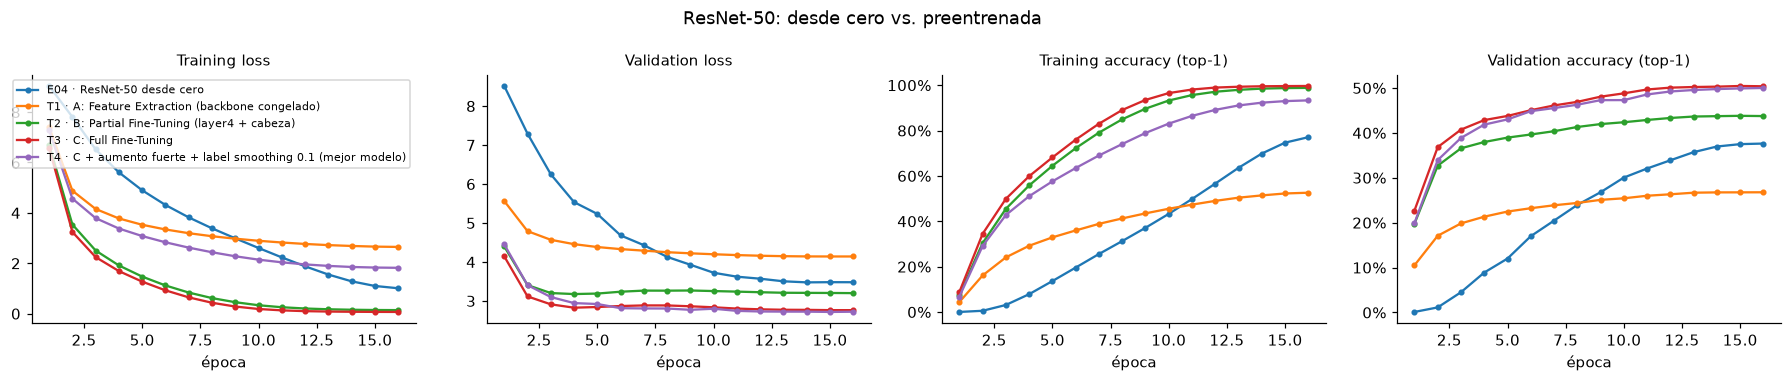

,descripción,top1,top5,f1_macro,f1_weighted,train_top1,brecha_top1,brecha_loss,mejor_ep,épocas,params_M,entrenables_M,GFLOPs,img_s,min_total,gpu,top1 época 1,época 90%
ID,,,,,,,,,,,,,,,,,,
E04,ResNet-50 desde cero,37.6%,60.4%,37.1%,37.1%,77.1%,39.5%,2.47,16,16,44.0,44.0,2.71,1763,75,RTX A6000,0.1%,12
T1,A: Feature Extraction (backbone congelado),26.7%,47.8%,25.6%,25.6%,52.6%,25.9%,1.49,16,16,44.0,20.5,2.71,4080,37,A100 MIG 2g.10gb,10.5%,8
T2,B: Partial Fine-Tuning (layer4 + cabeza),43.8%,65.9%,43.5%,43.5%,98.7%,54.9%,3.06,15,16,44.0,35.5,2.71,3453,44,A100 MIG 2g.10gb,19.8%,6
T3,C: Full Fine-Tuning,50.4%,72.1%,50.1%,50.1%,99.6%,49.2%,2.69,15,16,44.0,44.0,2.71,1444,115,A100 MIG 2g.10gb,22.7%,7
T4,C + aumento fuerte + label smoothing 0.1 (mejor modelo),50.0%,71.7%,49.7%,49.7%,93.3%,43.3%,0.90,16,16,44.0,44.0,2.71,2444,55,A100 MIG 3g.20gb,19.9%,7


In [3]:
curvas(R, ["E04", "T1", "T2", "T3", "T4"], "ResNet-50: desde cero vs. preentrenada")
t = tabla(R, ["E04", "T1", "T2", "T3", "T4"])
if len(t):
    t["top1 época 1"] = [R[i]["hist"].val_top1.iloc[0] for i in t.index]
    t["época 90%"] = [epoca_para(R, i) for i in t.index]
t.style.format(FMT | {"top1 época 1": "{:.1%}"}) if len(t) else None

**Sobre el coste:** los jobs cayeron en GPUs distintas (columna `gpu`), así que los **minutos no son
comparables entre filas**. Sí lo son T1, T2 y T3, que corrieron en el mismo tipo de GPU (una porción MIG
2g.10gb de A100). La medida independiente del hardware es GFLOPs × imágenes × épocas, pero no captura que
congelar capas ahorra el *backward*.

In [4]:
if {"E04", "T1", "T2", "T3"} <= set(R):
    g = {i: R[i]["resumen"]["val_top1"] for i in ["E04", "T1", "T2", "T3"]}
    v = {i: tabla(R, [i]).img_s.iloc[0] for i in ["T1", "T2", "T3"]}
    print(f"Aporte del preentrenamiento (T3 − E04): {g['T3'] - g['E04']:+.1%}")
    print(f"Aporte del fine-tuning completo (T3 − T1): {g['T3'] - g['T1']:+.1%}")
    print(f"Parcial captura {(g['T2'] - g['T1']) / (g['T3'] - g['T1']):.0%} de esa mejora")
    print(f"Velocidad en la misma GPU: T1 {v['T1']:.0f} · T2 {v['T2']:.0f} · T3 {v['T3']:.0f} img/s "
          f"→ T3 es {v['T1'] / v['T3']:.1f}× más lento que T1 y {v['T2'] / v['T3']:.1f}× más que T2")

Aporte del preentrenamiento (T3 − E04): +12.8%
Aporte del fine-tuning completo (T3 − T1): +23.8%
Parcial captura 72% de esa mejora
Velocidad en la misma GPU: T1 4080 · T2 3453 · T3 1444 img/s → T3 es 2.8× más lento que T1 y 2.4× más que T2


## 3. Lectura

| | Top-1 | Top-5 | Macro-F1 | Top-1 en época 1 |
|---|---|---|---|---|
| E04 desde cero | 37,6 % | 60,4 % | 37,1 % | 0,1 % |
| T1 · A congelado | 26,7 % | 47,8 % | 25,6 % | 10,5 % |
| T2 · B parcial | 43,8 % | 65,9 % | 43,5 % | 19,8 % |
| **T3 · C completo** | **50,4 %** | **72,1 %** | **50,1 %** | 22,7 % |
| T4 · C + aumento + LS | 50,0 % | 71,7 % | 49,7 % | 19,9 % |

* **Cuánto aporta el preentrenamiento:** T3 − E04 = **+12,8 pp** con la misma red y las mismas épocas.
  Además converge mucho más rápido: T3 tiene 22,7 % tras **una** época, mientras E04 necesita 8 épocas
  para llegar ahí. Con 16 épocas, E04 aún no convergió, así que la ventaja final del preentrenamiento
  podría reducirse con un entrenamiento más largo. La ventaja en convergencia es indiscutible.
  → **H1 (≥ 15 pp) se rechaza** con este presupuesto: la mejora es clara, pero menor que la predicha.
* **Cuánto aporta el fine-tuning:** T3 − T1 = **+23,8 pp** → **H2 (≥ 5 pp) se acepta con holgura.**
  Resultado llamativo: **el backbone congelado (T1) rinde menos que entrenar desde cero (E04)**. Dos
  causas: (1) los rasgos de ImageNet (1 000 clases, pocos organismos y muy distintos entre sí) no separan
  especies congenéricas; (2) la resolución: los pesos se aprendieron a 224 px y aquí se usan a 128. Los
  filtros esperan objetos más grandes en píxeles, y un backbone congelado no puede recalibrarse.
* **Partial fine-tuning, la mejor relación coste/beneficio:** descongelar solo `layer4` recupera el **72 %**
  de la mejora de T1 a T3, y en la misma GPU es solo ~1,2× más lento que T1 (T3 es ~2,8×).
* **¿Se justifica el full fine-tuning?** Da +6,6 pp más que el parcial por ~2,4× el tiempo. Si importa la
  accuracy (el caso de la tarea), sí. Con presupuesto limitado, el parcial es la opción eficiente.
* **Estabilidad y generalización:** ninguna corrida fue inestable (norma media del gradiente ~3). T2 y T3
  llegan a **99 % en train** con ~44–50 % en val: memorizan el conjunto de entrenamiento, aunque la
  validación sigue mejorando. T4 (aumento fuerte + label smoothing) reduce el train top-1 a 93 % pero **no
  mejora la validación** (50,0 % frente a 50,4 %, dentro del ruido de una sola semilla): con 16 épocas, la
  regularización extra no alcanza a traducirse en acierto.